## Model Training

#### 1.1 Import Dataset and Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### 1.2 Import Model Algorithms

In [20]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score, log_loss
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier, RadiusNeighborsRegressor, RadiusNeighborsClassifier, NearestCentroid, LocalOutlierFactor
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor, DecisionTreeClassifier, ExtraTreeClassifier, plot_tree, export_text, export_graphviz, _tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor, ExtraTreesRegressor, StackingRegressor, VotingRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR, LinearSVR, NuSVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor, TheilSenRegressor, PoissonRegressor, GammaRegressor, TweedieRegressor, RANSACRegressor, OrthogonalMatchingPursuit, Lars, LarsCV, ARDRegression, PassiveAggressiveRegressor, SGDRegressor, Perceptron, RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from joblib import Parallel, delayed


#### 1.3 Import the CSV data

In [21]:
df = pd.read_csv('data/stud.csv')

In [22]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### 2. Data Preprocessing

In [23]:
X = df.drop(columns=['math_score'],axis=1)
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [24]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in 'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())


Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [25]:
y = df['math_score']

In [26]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [27]:
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [28]:
X = preprocessor.fit_transform(X)

In [29]:
X.shape

(1000, 19)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

#### 2.1 Create an Evaluate Function to Compare Models

In [31]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, mse, rmse, r2_square

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "BayesianRidge": BayesianRidge(),
    "HuberRegressor": HuberRegressor(),
    "TheilSenRegressor": TheilSenRegressor(),
    "PoissonRegressor": PoissonRegressor(),
    "GammaRegressor": GammaRegressor(),
    "TweedieRegressor": TweedieRegressor(),
    "RANSACRegressor": RANSACRegressor(),
    "Lars": Lars(eps=1e-3),
    "LarsCV": LarsCV(eps=1e-3, max_iter=1000),
    "ARDRegression": ARDRegression(),
    "SGDRegressor": SGDRegressor(max_iter=5000, tol=1e-3, random_state=42),
    "PassiveAggressiveRegressor": PassiveAggressiveRegressor(max_iter=5000, tol=1e-3, random_state=42),
    "OrthogonalMatchingPursuit": OrthogonalMatchingPursuit(),
    "RidgeCV": RidgeCV(),
    "LassoCV": LassoCV(max_iter=5000),
    "ElasticNetCV": ElasticNetCV(max_iter=5000),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Extra Tree Regressor": ExtraTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "Extra Trees Regressor": ExtraTreesRegressor(random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42),
    "AdaBoost Regressor": AdaBoostRegressor(random_state=42),
    "Bagging Regressor": BaggingRegressor(random_state=42),
    "Stacking Regressor": StackingRegressor(estimators=[("lr", LinearRegression()), ("ridge", Ridge())]),
    "Voting Regressor": VotingRegressor(estimators=[("lr", LinearRegression()), ("ridge", Ridge())]),
    "HistGradientBoostingRegressor": HistGradientBoostingRegressor(random_state=42),
    "SVR": SVR(),
    "LinearSVR": LinearSVR(dual="auto", max_iter=5000, random_state=42), # type: ignore
    "NuSVR": NuSVR(),
    "XGBRegressor": XGBRegressor(verbosity=0, random_state=42),
    "LGBMRegressor": LGBMRegressor(verbose=-1, random_state=42),
    "CatBoostRegressor": CatBoostRegressor(verbose=False, random_state=42),
}

model_list = []
r2_list = []
cv_scores_list = []

X_train_dense = X_train.toarray() if hasattr(X_train, "toarray") else X_train
X_test_dense = X_test.toarray() if hasattr(X_test, "toarray") else X_test


def run_model(model_name, model):

    try:
        if model_name == "GammaRegressor" and (np.asarray(y_train) <= 0).any():
            return {"status": "fail", "Model": model_name, "error": "GammaRegressor needs y > 0"}

        model.fit(X_train_dense, y_train)
        y_train_pred = model.predict(X_train_dense)
        y_test_pred = model.predict(X_test_dense)

        model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
        model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

        try:
            cv_scores = cross_val_score(model, X_train_dense, y_train, cv=5, scoring="r2", error_score="raise")
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()

        except Exception:
            cv_mean = 0
            cv_std = 0

        return {
            "status": "ok",
            "Model": model_name,
            "train_rmse": model_train_rmse,
            "train_mse": model_train_mse,
            "train_mae": model_train_mae,
            "train_r2": model_train_r2,
            "test_rmse": model_test_rmse,
            "test_mse": model_test_mse,
            "test_mae": model_test_mae,
            "test_r2": model_test_r2,
            "cv_mean": cv_mean,
            "cv_std": cv_std,
        }

    except Exception as e:

        return {"status": "fail", "Model": model_name, "error": str(e)}

results = Parallel(n_jobs=-1, prefer="threads")(delayed(run_model)(name, mdl) for name, mdl in models.items())

for res in results:

    if res.get("status") == "ok": # type: ignore
        model_name = res["Model"] # type: ignore
        model_list.append(model_name)
        r2_list.append(res["test_r2"]) # type: ignore
        cv_scores_list.append(res["cv_mean"]) # type: ignore

        print(model_name)
        print("Model performance for Training set")
        print("- Root Mean Squared Error: {:.4f}".format(res["train_rmse"])) # type: ignore
        print("- Mean Squared Error: {:.4f}".format(res["train_mse"])) # type: ignore
        print("- Mean Absolute Error: {:.4f}".format(res["train_mae"])) # type: ignore
        print("- R2 Score: {:.4f}".format(res["train_r2"])) # type: ignore
        print("----------------------------------")
        print("Model performance for Test set")
        print("- Root Mean Squared Error: {:.4f}".format(res["test_rmse"])) # type: ignore
        print("- Mean Squared Error: {:.4f}".format(res["test_mse"])) # type: ignore
        print("- Mean Absolute Error: {:.4f}".format(res["test_mae"])) # type: ignore
        print("- R2 Score: {:.4f}".format(res["test_r2"])) # type: ignore

        if res["cv_mean"] != 0: # type: ignore
            print("----------------------------------")
            print("Cross-Validation Performance")
            print("- Mean CV R2 Score: {:.4f} (+/- {:.4f})".format(res["cv_mean"], res["cv_std"])) # type: ignore
        print("=" * 35)
        print("\n")

    else:
        print(f"{res['Model']} - FAILED") # type: ignore
        print(f"Error: {res.get('error')}") # type: ignore
        print("=" * 35)
        print("\n")


Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.3244
- Mean Squared Error: 28.3487
- Mean Absolute Error: 4.2671
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3960
- Mean Squared Error: 29.1167
- Mean Absolute Error: 4.2158
- R2 Score: 0.8803
----------------------------------
Cross-Validation Performance
- Mean CV R2 Score: 0.8684 (+/- 0.0110)


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.3233
- Mean Squared Error: 28.3378
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3904
- Mean Squared Error: 29.0563
- Mean Absolute Error: 4.2111
- R2 Score: 0.8806
----------------------------------
Cross-Validation Performance
- Mean CV R2 Score: 0.8686 (+/- 0.0118)


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5938
- Mean Squared Error: 43.4784
- Mea

In [33]:
results_df = pd.DataFrame(results)

successful_results = results_df[results_df['status'] == 'ok'].copy()

comparison_df = successful_results[['Model', 'train_rmse', 'test_rmse', 'train_r2', 'test_r2', 'cv_mean']].copy()
comparison_df = comparison_df.sort_values('test_r2', ascending=False)

print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("\n")

print("TOP 5 MODELS BY TEST R2 SCORE:")
print(comparison_df.head(5).to_string(index=False))

MODEL PERFORMANCE COMPARISON
                        Model  train_rmse  test_rmse  train_r2  test_r2  cv_mean
            TheilSenRegressor    5.345250   5.313761  0.873267 0.883964 0.867529
                ARDRegression    5.330167   5.333509  0.873981 0.883100 0.868437
               HuberRegressor    5.327777   5.371201  0.874094 0.881442 0.868086
                 SGDRegressor    5.329491   5.378582  0.874013 0.881116 0.867637
                       LarsCV    5.324836   5.380752  0.874233 0.881020 0.868153
                      LassoCV    5.324400   5.381905  0.874253 0.880969 0.868541
                 ElasticNetCV    5.346639   5.385836  0.873201 0.880795 0.867823
                    LinearSVR    5.370003   5.387601  0.872090 0.880717 0.865205
                BayesianRidge    5.323728   5.388663  0.874285 0.880670 0.868599
                        Ridge    5.323325   5.390387  0.874304 0.880593 0.868607
                      RidgeCV    5.323325   5.390387  0.874304 0.880593 0.868607

#### 3. TheilSenRegressor

In [34]:
main_model = TheilSenRegressor()
main_model.fit(X_train, y_train)
y_pred = main_model.predict(X_test)
mae, mse, rmse, r2 = evaluate_model(y_test, y_pred)
score = r2_score(y_test, y_pred)
print(f"accuracy score: {score} ")

accuracy score: 0.8836772954478403 


#### 3.1 Evaluate TheilSenRegressor Model

In [35]:
pred_df = pd.DataFrame(
    {
        'Actual Value': y_test,
        'Predicted Value': y_pred,
        'Difference': y_test - y_pred,
    }
)
pred_df.head()

,Actual Value,Predicted Value,Difference
521,91,76.444294,14.555706
737,53,58.657643,-5.657643
740,80,76.758964,3.241036
660,74,76.784571,-2.784571
411,84,87.058156,-3.058156


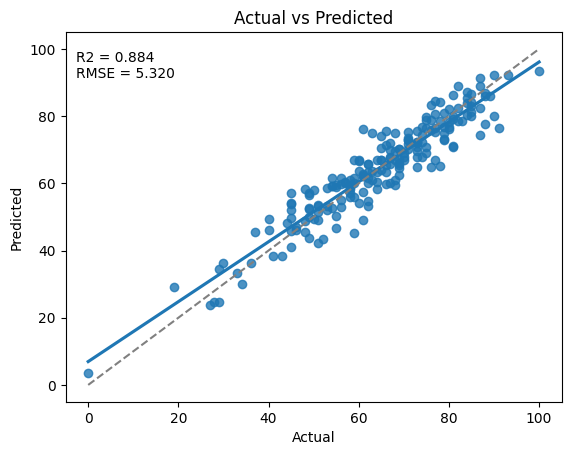

In [36]:
ax = sns.regplot(x=pred_df['Actual Value'], y=pred_df['Predicted Value'], ci=None)
ax.set_title('Actual vs Predicted')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')


min_val, max_val = pred_df['Actual Value'].min(), pred_df['Actual Value'].max()

plt.plot([min_val, max_val], [min_val, max_val], '--', color='gray')

plt.text(0.02, 0.95, f'R2 = {score:.3f}\nRMSE = {rmse:.3f}', transform=ax.transAxes, va='top')

plt.show()